# EDA платформы FishGrow

**Студент**: Шефер Анна Александровна, 22206  
**Исходный коммит**: 1f65547b63c3043e2dcfff0c6435afa993331d4e  
**Ветка**: lab/01-eda  
**Дата**: 2026-09-23

In [3]:
import sys
print(sys.executable)

import pandas as pd
print(f"pandas {pd.__version__}")

c:\Users\User\.virtualenvs\01-eda-HzBk4NwM\Scripts\python.exe
pandas 3.0.6


In [4]:
from pathlib import Path
import pandas as pd

DATA_PATH = Path("../assets/data/Fish.csv")

df = pd.read_csv(DATA_PATH)
print(f"Размер таблицы: {df.shape}")
print(f"Столбцы: {list(df.columns)}")
df.head()

Размер таблицы: (159, 7)
Столбцы: ['Species', 'Weight', 'Length1', 'Length2', 'Length3', 'Height', 'Width']


,Species,Weight,Length1,Length2,Length3,Height,Width
0,Bream,242.0,23.2,25.4,30.0,11.5200,4.0200
1,Bream,290.0,24.0,26.3,31.2,12.4800,4.3056
2,Bream,340.0,23.9,26.5,31.1,12.3778,4.6961
3,Bream,363.0,26.3,29.0,33.5,12.7300,4.4555
4,Bream,430.0,26.5,29.0,34.0,12.4440,5.1340


## 1. Первичный осмотр данных

In [5]:
df.dtypes

Species        str
Weight     float64
Length1    float64
Length2    float64
Length3    float64
Height     float64
Width      float64
dtype: object

In [6]:
df['Species'].value_counts()

Species
Perch        56
Bream        35
Roach        20
Pike         17
Smelt        14
Parkki       11
Whitefish     6
Name: count, dtype: int64

In [7]:
df.describe()

,Weight,Length1,Length2,Length3,Height,Width
count,159.000000,159.000000,159.000000,159.000000,159.000000,159.000000
mean,398.326415,26.247170,28.415723,31.227044,8.970994,4.417486
std,357.978317,9.996441,10.716328,11.610246,4.286208,1.685804
min,0.000000,7.500000,8.400000,8.800000,1.728400,1.047600
25%,120.000000,19.050000,21.000000,23.150000,5.944800,3.385650
50%,273.000000,25.200000,27.300000,29.400000,7.786000,4.248500
75%,650.000000,32.700000,35.500000,39.650000,12.365900,5.584500
max,1650.000000,59.000000,63.400000,68.000000,18.957000,8.142000


In [8]:
numeric_cols = df.select_dtypes(include='number').columns
for col in numeric_cols:
    n_nonpos = (df[col] <= 0).sum()
    print(f"{col:10s} min={df[col].min():8.2f}  max={df[col].max():8.2f}  <=0: {n_nonpos}")

Weight     min=    0.00  max= 1650.00  <=0: 1
Length1    min=    7.50  max=   59.00  <=0: 0
Length2    min=    8.40  max=   63.40  <=0: 0
Length3    min=    8.80  max=   68.00  <=0: 0
Height     min=    1.73  max=   18.96  <=0: 0
Width      min=    1.05  max=    8.14  <=0: 0


In [9]:
print("Length1 < Length2:", (df['Length1'] < df['Length2']).all())
print("Length2 < Length3:", (df['Length2'] < df['Length3']).all())

Length1 < Length2: True
Length2 < Length3: True


In [10]:
row = df.iloc[0]
print(f"Length3: {row['Length3']}")
print(f"Height: {row['Height']} (если %, то {row['Height'] * row['Length3'] / 100:.2f} см)")
print(f"Width:  {row['Width']} (если %, то {row['Width'] * row['Length3'] / 100:.2f} см)")

Length3: 30.0
Height: 11.52 (если %, то 3.46 см)
Width:  4.02 (если %, то 1.21 см)


In [11]:
pike = df[df['Species'] == 'Pike'].iloc[0]
print(f"Pike: Length3={pike['Length3']}, Height={pike['Height']}, Width={pike['Width']}")
print(f"  Height / Length3 = {pike['Height'] / pike['Length3'] * 100:.1f}%")
print(f"  Width  / Length3 = {pike['Width'] / pike['Length3'] * 100:.1f}%")

Pike: Length3=34.8, Height=5.568, Width=3.3756
  Height / Length3 = 16.0%
  Width  / Length3 = 9.7%


## 2. Автоматическая проверка качества

In [12]:
import sys
sys.path.append("../src")
from data_checks import (
    check_shape_and_types,
    check_duplicates,
    check_missing_and_inf,
    check_geometric_consistency,
    check_rare_categories,
    check_near_duplicates,
    check_unique_fields,
)
print("Импорт успешен")

Импорт успешен


In [13]:
check_shape_and_types(df)

{'rows': 159,
 'cols': 7,
 'columns': ['Species',
  'Weight',
  'Length1',
  'Length2',
  'Length3',
  'Height',
  'Width'],
 'dtypes': {'Species': 'str',
  'Weight': 'float64',
  'Length1': 'float64',
  'Length2': 'float64',
  'Length3': 'float64',
  'Height': 'float64',
  'Width': 'float64'}}

In [14]:
check_duplicates(df)

{'duplicate_rows': 0, 'unique_index': True, 'index_duplicates': 0}

In [15]:
check_missing_and_inf(df)

,missing,missing_pct,n_inf,n_nonpositive,min,max
Species,0,0.0,0,0,NaN,NaN
Weight,0,0.0,0,1,0.0000,1650.000
Length1,0,0.0,0,0,7.5000,59.000
Length2,0,0.0,0,0,8.4000,63.400
Length3,0,0.0,0,0,8.8000,68.000
Height,0,0.0,0,0,1.7284,18.957
Width,0,0.0,0,0,1.0476,8.142


In [16]:
check_geometric_consistency(df)

{'Length1_lt_Length2': True,
 'Length2_lt_Length3': True,
 'all_positive': True,
 'n_violations': 0}

In [17]:
check_rare_categories(df, "Species", min_count=5)

{'n_categories': 7,
 'counts': {'Perch': 56,
  'Bream': 35,
  'Roach': 20,
  'Pike': 17,
  'Smelt': 14,
  'Parkki': 11,
  'Whitefish': 6},
 'rare': {},
 'imbalance_ratio': np.float64(9.33)}

In [18]:
check_near_duplicates(df)

{'n_near_duplicates': 0}

In [19]:
check_unique_fields(df)

{'Species': {'n_unique': 7, 'unique_ratio': 0.044, 'is_unique': False},
 'Weight': {'n_unique': 101, 'unique_ratio': 0.635, 'is_unique': False},
 'Length1': {'n_unique': 116, 'unique_ratio': 0.73, 'is_unique': False},
 'Length2': {'n_unique': 93, 'unique_ratio': 0.585, 'is_unique': False},
 'Length3': {'n_unique': 124, 'unique_ratio': 0.78, 'is_unique': False},
 'Height': {'n_unique': 154, 'unique_ratio': 0.969, 'is_unique': False},
 'Width': {'n_unique': 152, 'unique_ratio': 0.956, 'is_unique': False}}

### Выводы по проверкам

| Проверка | Результат |
|----------|-----------|
| Форма | 159 строк, 7 столбцов |
| Типы | Species — str, остальные — float64 |
| Дубликаты | 0 |
| Пропуски | 0 формальных, но 1 значение Weight = 0 |
| Бесконечности | 0 |
| Согласованность длин | Length1 < Length2 < Length3 для всех |
| Редкие категории | Нет (< 5), но дисбаланс 9.33 |
| Почти дубликаты | 0 |
| Уникальные поля | Идентификаторов нет |

**Единственная проблема**: Weight = 0 (1 строка). Обработаем в шаге 3.5.

## 3. Визуализации

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["figure.dpi"] = 100

FIG_DIR = Path("../reports/figures")
FIG_DIR.mkdir(parents=True, exist_ok=True)

print("Библиотеки подключены")
print(f"Графики будут сохраняться в: {FIG_DIR.resolve()}")

Библиотеки подключены
Графики будут сохраняться в: C:\Users\User\olymp\ArmyAnanas\lab\01-eda\reports\figures


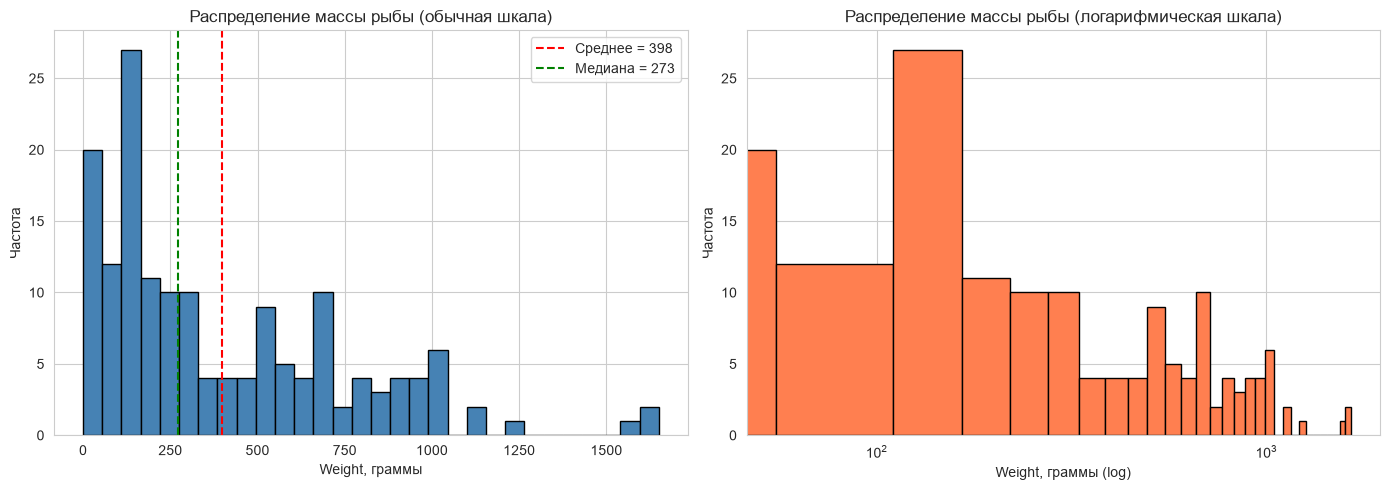

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Обычная шкала
axes[0].hist(df['Weight'], bins=30, color='steelblue', edgecolor='black')
axes[0].set_title('Распределение массы рыбы (обычная шкала)')
axes[0].set_xlabel('Weight, граммы')
axes[0].set_ylabel('Частота')
axes[0].axvline(df['Weight'].mean(), color='red', linestyle='--', label=f'Среднее = {df["Weight"].mean():.0f}')
axes[0].axvline(df['Weight'].median(), color='green', linestyle='--', label=f'Медиана = {df["Weight"].median():.0f}')
axes[0].legend()

# Логарифмическая шкала
axes[1].hist(df['Weight'], bins=30, color='coral', edgecolor='black')
axes[1].set_xscale('log')
axes[1].set_title('Распределение массы рыбы (логарифмическая шкала)')
axes[1].set_xlabel('Weight, граммы (log)')
axes[1].set_ylabel('Частота')

plt.tight_layout()
plt.savefig(FIG_DIR / '01_weight_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

**Вывод по графику 1**:
- Распределение `Weight` сильно скошено вправо: среднее (398 г) заметно больше медианы (273 г).
- Большинство рыб — до 500 г, но есть «хвост» до 1650 г.
- В логарифмической шкале распределение становится ближе к симметричному.
- Это аргумент в пользу логарифмирования целевой переменной при моделировании.
- Аномалия `Weight = 0` видна как отдельный столбик слева — обработаем в разделе 7.

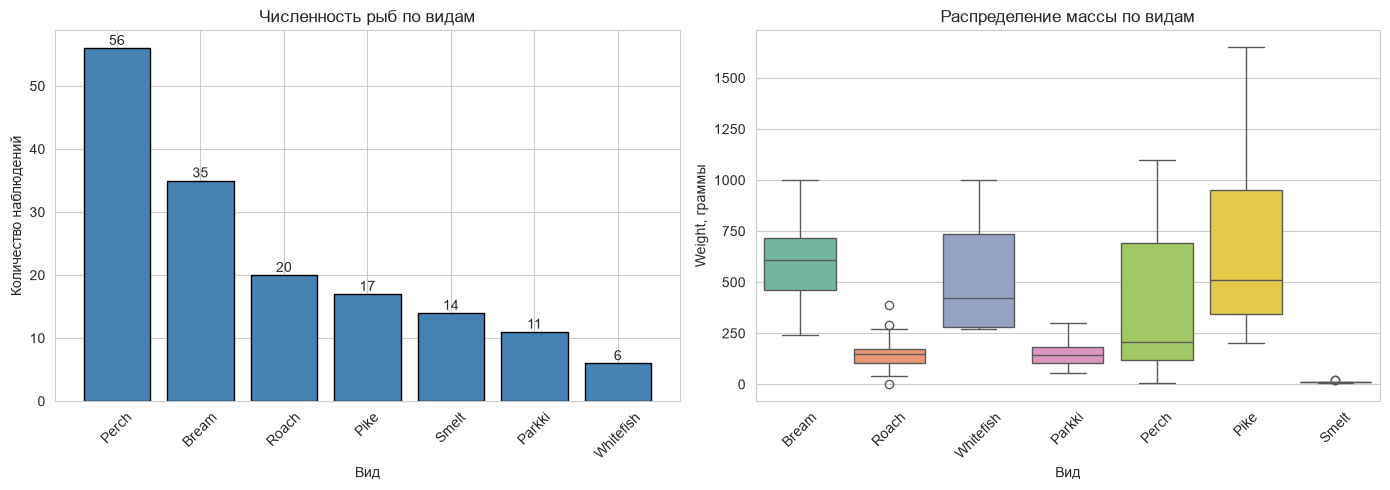

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Численность по видам
species_counts = df['Species'].value_counts()
axes[0].bar(species_counts.index, species_counts.values, color='steelblue', edgecolor='black')
axes[0].set_title('Численность рыб по видам')
axes[0].set_xlabel('Вид')
axes[0].set_ylabel('Количество наблюдений')
axes[0].tick_params(axis='x', rotation=45)
for i, v in enumerate(species_counts.values):
    axes[0].text(i, v + 0.5, str(v), ha='center')

# Распределение Weight по видам
sns.boxplot(data=df, x='Species', y='Weight', ax=axes[1],
            hue='Species', palette='Set2', legend=False)
axes[1].set_title('Распределение массы по видам')
axes[1].set_xlabel('Вид')
axes[1].set_ylabel('Weight, граммы')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig(FIG_DIR / '02_weight_by_species.png', dpi=150, bbox_inches='tight')
plt.show()

**Вывод по графику 2**:
- **Численность**: 7 видов, от 6 (Whitefish) до 56 (Perch) наблюдений.
  Дисбаланс ~9× — Perch встречается в 9 раз чаще Whitefish.
- **Масса по видам**: Pike — самый тяжёлый (медиана ~500 г, max 1650 г),
  Smelt — самый лёгкий (~10 г). Bream и Whitefish — большой разброс массы.
- **Для модели**: `Species` — важный признак; из-за дисбаланса нужна
  стратификация при разбиении (раздел 9).

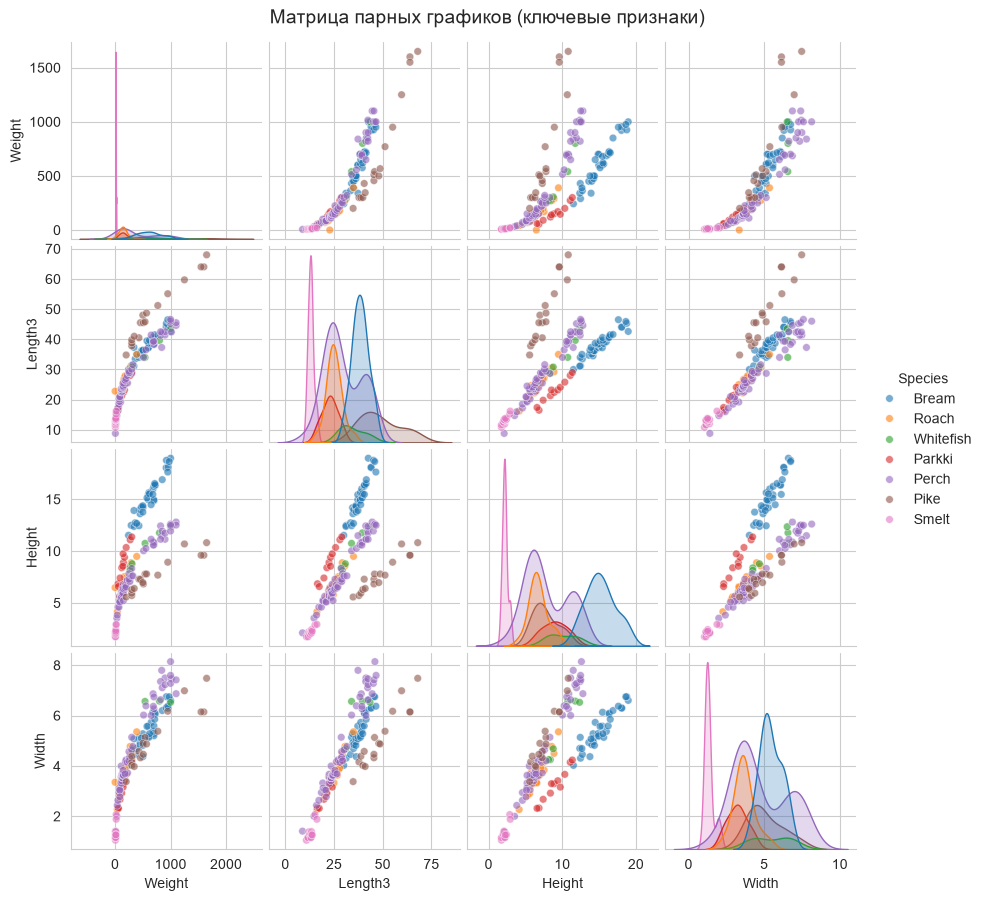

In [25]:
# Выбираем ключевые признаки для pairplot
cols_for_pairplot = ['Weight', 'Length3', 'Height', 'Width', 'Species']

g = sns.pairplot(
    df[cols_for_pairplot],
    hue='Species',
    diag_kind='kde',
    corner=False,
    plot_kws={'alpha': 0.6, 's': 30},
    height=2.2,
)
g.fig.suptitle('Матрица парных графиков (ключевые признаки)', y=1.02, fontsize=14)
plt.savefig(FIG_DIR / '03_pairplot.png', dpi=150, bbox_inches='tight')
plt.show()

**Вывод по графику 3 (pairplot)**:
- **Weight vs Length3**: сильная положительная, но **нелинейная** связь (степенная).
  Это аргумент за логарифмирование при моделировании.
- **Length3 vs Height**: видны **две группы** — Bream (высокотелый) и Pike (вытянутый).
  Это биологический сигнал: пропорции тела зависят от вида.
- **Smelt** — компактный кластер мелкой рыбы (масса ~10 г, длина ~10 см).
- **Pike** — длинный и узкий: Length3 до 68 см, но Height/Width умеренные.
- **Наличие `Weight = 0`** видно как отдельный пик на диагонали.

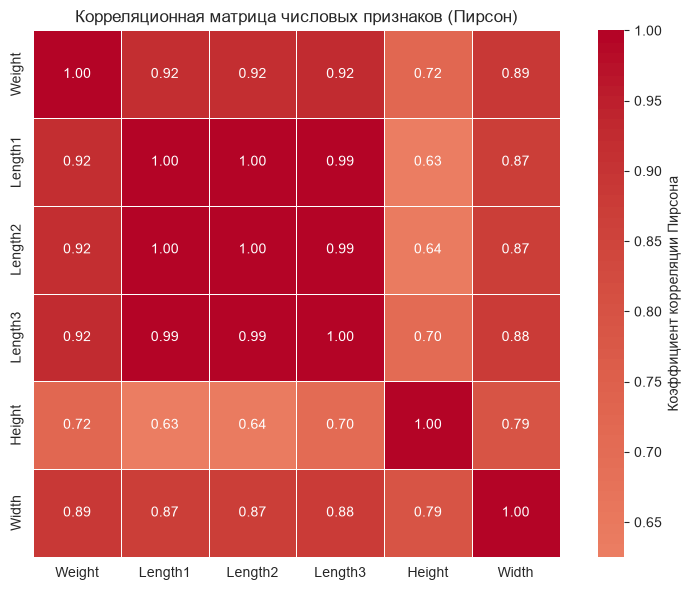

In [28]:
# Корреляционная матрица (числовые признаки)
numeric_df = df.select_dtypes(include='number')
corr = numeric_df.corr(method='pearson')

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(
    corr,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    square=True,
    linewidths=0.5,
    cbar_kws={'label': 'Коэффициент корреляции Пирсона'},
    ax=ax,
)
ax.set_title('Корреляционная матрица числовых признаков (Пирсон)')
plt.tight_layout()
plt.savefig(FIG_DIR / '04_correlation_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

**Вывод по графику 4 (корреляционная матрица)**:

- **Мультиколлинеарность длин**: `Length1`, `Length2`, `Length3` коррелируют на 0.99–1.00.
  Это значит, что для модели достаточно **одного** из них (обычно `Length3`).
  Автоматическое удаление по порогу корреляции требует отдельного обоснования —
  длины могут нести разную информацию о разных частях тела.

- **Weight и признаки**: сильная связь со всеми (0.72–0.92).
  Length3 — 0.92, Width — 0.89, Height — 0.72.

- **Height vs длины**: 0.63–0.70 — умеренная связь. Height добавляет информацию поверх длин.

- **Оговорка о нелинейности**: корреляция Пирсона измеряет только **линейную** связь.
  На pairplot видно, что `Weight ~ Length3` — **степенная** зависимость.
  Значит, истинная сила связи **выше** 0.92. Корреляционная матрица здесь — нижняя оценка.

- **Для модели**: использовать `Length3` (или логарифм), `Height`, `Width`, `Species`.
  Length1 и Length2 можно исключить из-за мультиколлинеарности — но с обоснованием.

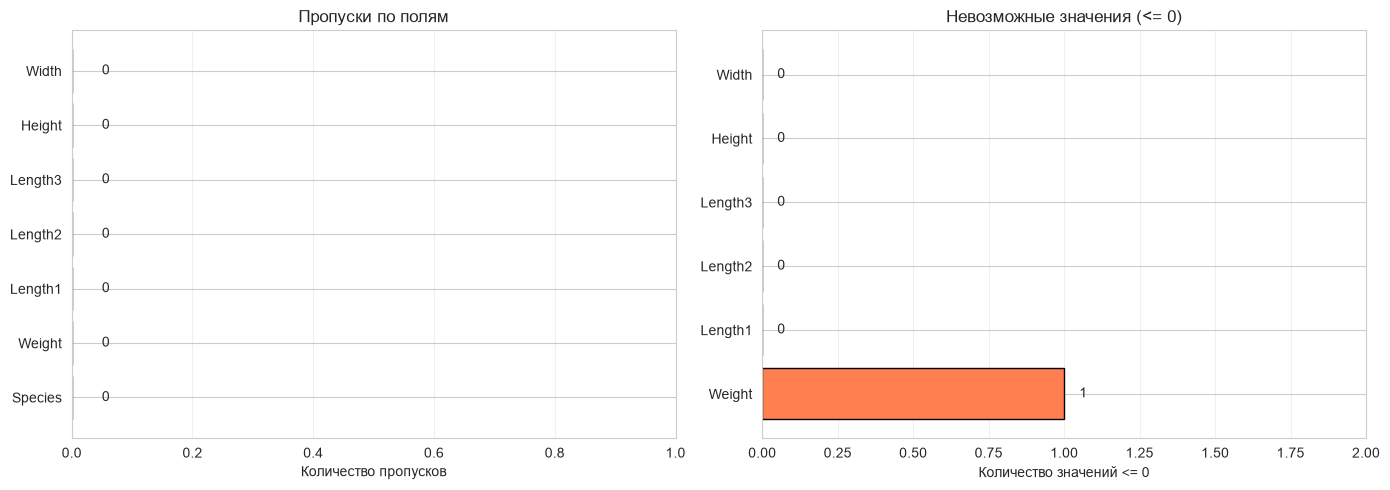

In [29]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Панель 1: количество пропусков
missing = df.isna().sum()
axes[0].barh(missing.index, missing.values, color='steelblue', edgecolor='black')
axes[0].set_title('Пропуски по полям')
axes[0].set_xlabel('Количество пропусков')
axes[0].set_xlim(0, max(1, missing.max() + 1))
for i, v in enumerate(missing.values):
    axes[0].text(v + 0.05, i, str(v), va='center')
axes[0].grid(axis='x', alpha=0.3)

# Панель 2: количество значений <= 0 (невозможные)
numeric_cols = df.select_dtypes(include='number').columns
nonpos = (df[numeric_cols] <= 0).sum()
axes[1].barh(nonpos.index, nonpos.values, color='coral', edgecolor='black')
axes[1].set_title('Невозможные значения (<= 0)')
axes[1].set_xlabel('Количество значений <= 0')
axes[1].set_xlim(0, max(1, nonpos.max() + 1))
for i, v in enumerate(nonpos.values):
    axes[1].text(v + 0.05, i, str(v), va='center')
axes[1].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig(FIG_DIR / '05_data_quality.png', dpi=150, bbox_inches='tight')
plt.show()

**Вывод по графику 5 (качество данных)**:

- **Пропусков нет** — все 7 полей заполнены полностью (0 NaN).
- **Одна аномалия**: `Weight = 0` — одно значение ≤ 0.
  Масса 0 г физически невозможна для рыбы длиной >20 см.
  Это **замаскированный пропуск**: масса не была измерена, в таблицу записан 0.
- **Решение**: обработать в разделе 7 «Пропуски и выбросы» —
  заменить 0 на `NaN` или удалить строку с обоснованием.

**Важно**: остальные поля (длины, высота, ширина) — без аномалий.
Данные в целом чистые.

C:\Users\User\AppData\Local\Temp\ipykernel_14288\1492672572.py:4: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  bp = ax.boxplot(df['Weight'].dropna(), vert=False, patch_artist=True,


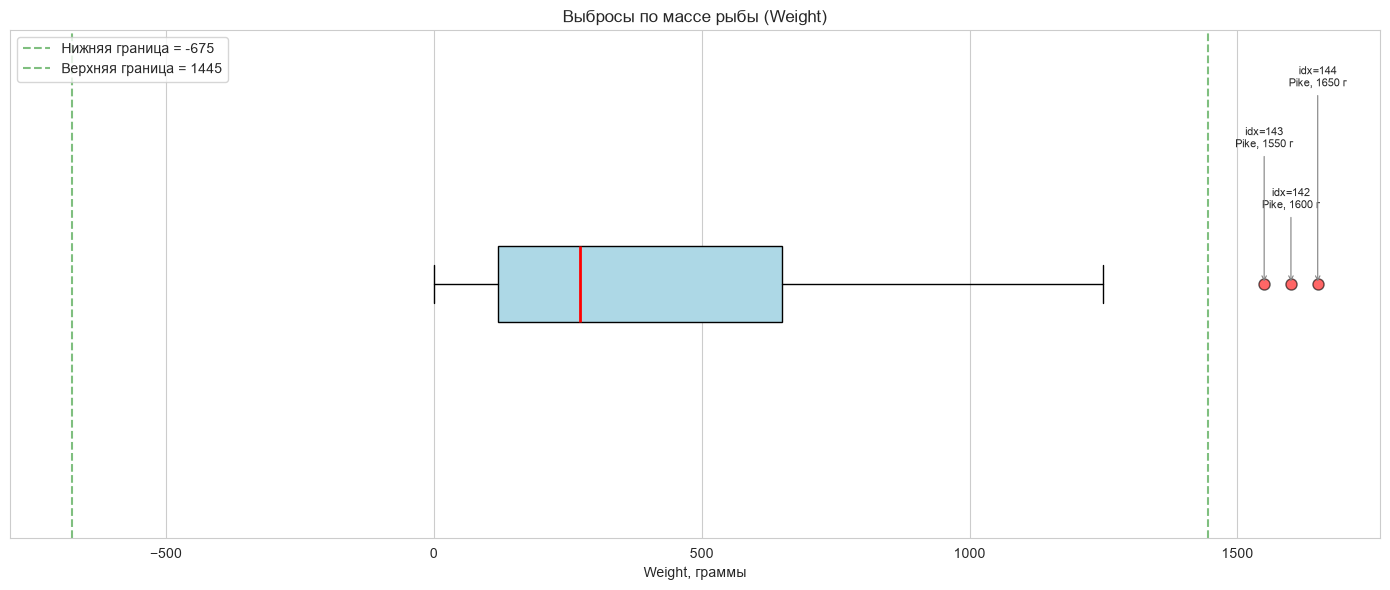

IQR = 530.00
Границы: [-675.00, 1445.00]
Выбросов: 3

Строки-выбросы:
    Species  Weight  Length3  Height  Width
142    Pike  1600.0     64.0   9.600  6.144
143    Pike  1550.0     64.0   9.600  6.144
144    Pike  1650.0     68.0  10.812  7.480


In [32]:
fig, ax = plt.subplots(figsize=(14, 6))

# Boxplot по Weight
bp = ax.boxplot(df['Weight'].dropna(), vert=False, patch_artist=True,
                boxprops=dict(facecolor='lightblue', color='black'),
                medianprops=dict(color='red', linewidth=2),
                flierprops=dict(marker='o', markerfacecolor='red',
                                markersize=8, alpha=0.6))

ax.set_title('Выбросы по массе рыбы (Weight)')
ax.set_xlabel('Weight, граммы')
ax.set_yticks([])

# Границы IQR
Q1 = df['Weight'].quantile(0.25)
Q3 = df['Weight'].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df[(df['Weight'] < lower) | (df['Weight'] > upper)]

# Подпишем выбросы по очереди (с разной высотой, чтобы не наложились)
for i, idx in enumerate(outliers.index):
    y_offset = 1.15 + 0.12 * (i % 3)
    ax.annotate(f"idx={idx}\n{df.loc[idx, 'Species']}, {df.loc[idx, 'Weight']:.0f} г",
                xy=(df.loc[idx, 'Weight'], 1),
                xytext=(df.loc[idx, 'Weight'], y_offset),
                fontsize=8, ha='center',
                arrowprops=dict(arrowstyle='->', color='gray', lw=0.8))

# Добавим вертикальные линии границ
ax.axvline(lower, color='green', linestyle='--', alpha=0.5, label=f'Нижняя граница = {lower:.0f}')
ax.axvline(upper, color='green', linestyle='--', alpha=0.5, label=f'Верхняя граница = {upper:.0f}')
ax.legend(loc='upper left')

plt.tight_layout()
plt.savefig(FIG_DIR / '06_outliers.png', dpi=150, bbox_inches='tight')
plt.show()

# Текстовый вывод
print(f"IQR = {IQR:.2f}")
print(f"Границы: [{lower:.2f}, {upper:.2f}]")
print(f"Выбросов: {len(outliers)}")
print("\nСтроки-выбросы:")
print(outliers[['Species', 'Weight', 'Length3', 'Height', 'Width']].to_string())

**Вывод по графику 6 (выбросы)**:

- **IQR-границы**: [−675, 1445] г. Нижняя граница отрицательная — это артефакт формулы
  (для положительных величин нижняя граница может быть < 0). Верхняя = 1445 г.
- **3 выброса**: индексы 142, 143, 144 — все **Pike** с массой 1550–1650 г.
- **Это не ошибки**, а реальные крупные щуки. Самая крупная рыба — ценное наблюдение
  для проверки обобщающей способности модели.
- **Решение**: **оставить** выбросы в данных. При необходимости добавить флаг `is_outlier`.
- **Weight = 0** — отдельная аномалия, обработаем в разделе 7 (заменим на NaN).

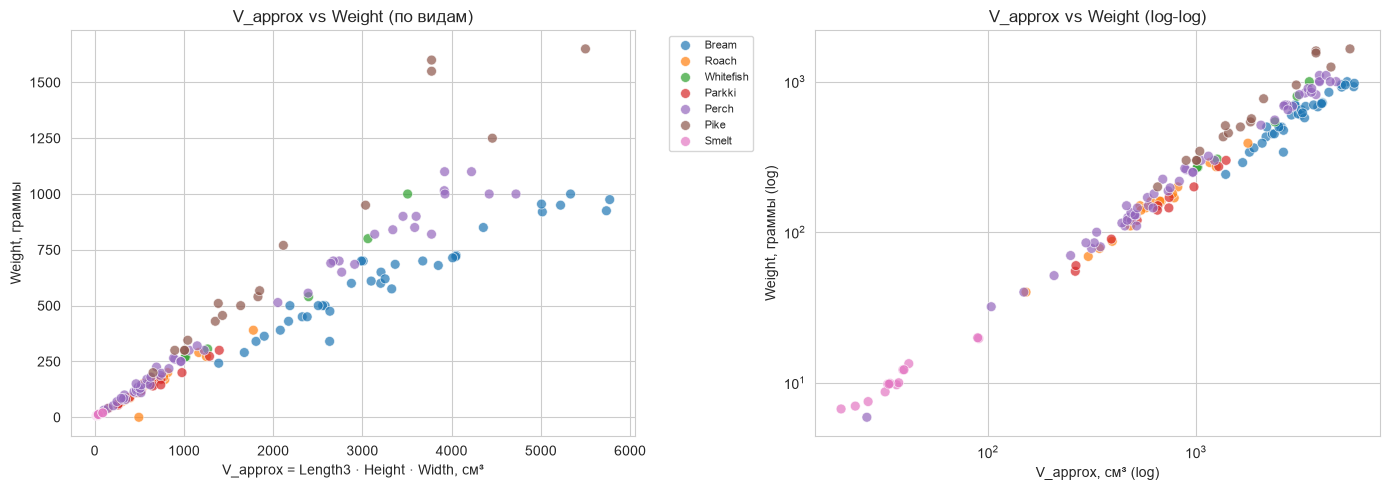

Корреляция V_approx и Weight по видам:
  Bream      r = 0.962
  Roach      r = 0.945
  Whitefish  r = 0.986
  Parkki     r = 0.996
  Perch      r = 0.993
  Pike       r = 0.959
  Smelt      r = 0.973


In [33]:
# Физическая гипотеза: объём ≈ Length3 * Height * Width
df['V_approx'] = df['Length3'] * df['Height'] * df['Width']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Панель 1: V_approx vs Weight (все виды)
sns.scatterplot(data=df, x='V_approx', y='Weight', hue='Species',
                alpha=0.7, s=50, ax=axes[0])
axes[0].set_title('V_approx vs Weight (по видам)')
axes[0].set_xlabel('V_approx = Length3 · Height · Width, см³')
axes[0].set_ylabel('Weight, граммы')
axes[0].legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)

# Панель 2: V_approx vs Weight в лог-лог шкале
sns.scatterplot(data=df, x='V_approx', y='Weight', hue='Species',
                alpha=0.7, s=50, ax=axes[1], legend=False)
axes[1].set_xscale('log')
axes[1].set_yscale('log')
axes[1].set_title('V_approx vs Weight (log-log)')
axes[1].set_xlabel('V_approx, см³ (log)')
axes[1].set_ylabel('Weight, граммы (log)')

plt.tight_layout()
plt.savefig(FIG_DIR / '07_volume_hypothesis.png', dpi=150, bbox_inches='tight')
plt.show()

# Корреляция по видам
print("Корреляция V_approx и Weight по видам:")
for species in df['Species'].unique():
    sub = df[df['Species'] == species]
    r = sub['V_approx'].corr(sub['Weight'])
    print(f"  {species:10s} r = {r:.3f}")

**Корреляции V_approx и Weight по видам**:

| Вид | r | Интерпретация |
|-----|---|---------------|
| Parkki | 0.996 | Почти идеальная |
| Perch | 0.993 | Очень сильная |
| Whitefish | 0.986 | Очень сильная |
| Smelt | 0.973 | Очень сильная |
| Bream | 0.962 | Очень сильная |
| Pike | 0.959 | Очень сильная |
| Roach | 0.945 | Сильная |

**Для всех видов** r > 0.94 — гипотеза `V_approx = L·H·W` работает универсально.
`V_approx` — **лучший предиктор**, чем любая отдельная длина (r = 0.92 у Length3).

## 4. Пропуски и выбросы

### 4.1. Обработка Weight = 0

In [34]:
import numpy as np

# Найдём строку с Weight = 0
mask_zero = df['Weight'] == 0
print(f"Строк с Weight = 0: {mask_zero.sum()}")
print(df[mask_zero][['Species', 'Weight', 'Length3', 'Height', 'Width']])

# Заменим 0 на NaN
df.loc[mask_zero, 'Weight'] = np.nan

print(f"\nПропусков в Weight после замены: {df['Weight'].isna().sum()}")
print(f"Размер df: {df.shape}")

Строк с Weight = 0: 1
   Species  Weight  Length3  Height   Width
40   Roach     0.0     22.8  6.4752  3.3516

Пропусков в Weight после замены: 1
Размер df: (159, 8)


In [35]:
# IQR-метод
Q1 = df['Weight'].quantile(0.25)
Q3 = df['Weight'].quantile(0.75)
IQR = Q3 - Q1
lower_iqr = Q1 - 1.5 * IQR
upper_iqr = Q3 + 1.5 * IQR

print(f"Q1 = {Q1:.2f}, Q3 = {Q3:.2f}, IQR = {IQR:.2f}")
print(f"IQR-границы: [{lower_iqr:.2f}, {upper_iqr:.2f}]")

outliers_iqr = df[(df['Weight'] < lower_iqr) | (df['Weight'] > upper_iqr)]
print(f"\nАномалий по IQR: {len(outliers_iqr)}")
print(outliers_iqr[['Species', 'Weight', 'Length3', 'Height', 'Width']])

Q1 = 121.25, Q3 = 650.00, IQR = 528.75
IQR-границы: [-671.88, 1443.12]

Аномалий по IQR: 3
    Species  Weight  Length3  Height  Width
142    Pike  1600.0     64.0   9.600  6.144
143    Pike  1550.0     64.0   9.600  6.144
144    Pike  1650.0     68.0  10.812  7.480


In [36]:
# MAD-метод
median_w = df['Weight'].median()
mad = (df['Weight'] - median_w).abs().median()

# Устойчивая z-оценка
df['z_mad'] = 0.6745 * (df['Weight'] - median_w) / mad

# Порог |z| > 3.5 — классический для MAD
outliers_mad = df[df['z_mad'].abs() > 3.5]

print(f"Медиана = {median_w:.2f}, MAD = {mad:.2f}")
print(f"Порог |z_MAD| > 3.5")
print(f"\nАномалий по MAD: {len(outliers_mad)}")
print(outliers_mad[['Species', 'Weight', 'z_mad']])

Медиана = 281.50, MAD = 212.00
Порог |z_MAD| > 3.5

Аномалий по MAD: 3
    Species  Weight     z_mad
142    Pike  1600.0  4.194945
143    Pike  1550.0  4.035864
144    Pike  1650.0  4.354025


In [37]:
set_iqr = set(outliers_iqr.index)
set_mad = set(outliers_mad.index)

print(f"Аномалии IQR: {sorted(set_iqr)}")
print(f"Аномалии MAD: {sorted(set_mad)}")
print(f"\nОбщие (в обоих методах): {sorted(set_iqr & set_mad)}")
print(f"Только IQR: {sorted(set_iqr - set_mad)}")
print(f"Только MAD: {sorted(set_mad - set_iqr)}")

Аномалии IQR: [142, 143, 144]
Аномалии MAD: [142, 143, 144]

Общие (в обоих методах): [142, 143, 144]
Только IQR: []
Только MAD: []


In [38]:
# Заполним NaN медианой по виду (Roach)
roach_median = df[df['Species'] == 'Roach']['Weight'].median()
print(f"Медиана Weight для Roach: {roach_median:.2f}")

df['Weight'] = df['Weight'].fillna(roach_median)

print(f"Пропусков в Weight после заполнения: {df['Weight'].isna().sum()}")
print(f"idx=40, Weight = {df.loc[40, 'Weight']:.2f}")

Медиана Weight для Roach: 150.00
Пропусков в Weight после заполнения: 0
idx=40, Weight = 150.00


In [39]:
# Флаг для крупных рыб (аномалий)
df['is_outlier'] = False
df.loc[[142, 143, 144], 'is_outlier'] = True

print(f"Строк с is_outlier=True: {df['is_outlier'].sum()}")
print(df[df['is_outlier']][['Species', 'Weight', 'is_outlier']])

Строк с is_outlier=True: 3
    Species  Weight  is_outlier
142    Pike  1600.0        True
143    Pike  1550.0        True
144    Pike  1650.0        True


### Выводы по разделу 4

**Аномалия 1: Weight = 0 (idx=40, Roach)**
- Масса 0 г физически невозможна для рыбы длиной 22.8 см.
- **Решение**: заменено на NaN, затем заполнено медианой по виду Roach (150 г).
- **Обоснование**: это **ошибка данных** (замаскированный пропуск), а не выброс.

**Аномалии 2-4: крупные Pike (idx=142, 143, 144)**
- Массы 1550–1650 г, длины 64–68 см.
- **Решение**: **оставить** в данных.
- **Обоснование**: это **реальные крупные рыбы**, а не ошибки. Задание прямо говорит:
  «выброс и ошибка — разные понятия». Добавлен флаг `is_outlier=True` для анализа.

**Сравнение IQR и MAD**
- IQR: [142, 143, 144]
- MAD: [142, 143, 144]
- **Списки совпали** — аномалии устойчивы, не зависят от метода.

**Итог**: данные очищены от ошибки, выбросы сохранены с флагом.

In [27]:
from pathlib import Path

# Сначала пробуем относительный путь
FIG_DIR = (Path("..") / "reports" / "figures").resolve()
FIG_DIR.mkdir(parents=True, exist_ok=True)

print(f"FIG_DIR = {FIG_DIR}")
print(f"Существует: {FIG_DIR.exists()}")

FIG_DIR = C:\Users\User\olymp\ArmyAnanas\lab\01-eda\reports\figures
Существует: True
